## Penguins — Sex Classification Pipeline
Continued from data cleaning. `penguins_clean` (333 rows, no nulls) and `penguins_unknown_sex` (9 rows) are assumed to be in scope.

### 1. Prepare features and target

In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler, LabelEncoder, RobustScaler, MinMaxScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, cross_val_score, StratifiedKFold
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
import numpy as np

penguins_clean = pd.read_csv('./data/penguins_clean.csv')

# Encode species (categorical) and target (sex)
le_species = LabelEncoder()
le_sex     = LabelEncoder()

df = penguins_clean.copy()
df['species_enc'] = le_species.fit_transform(df['species'])
df['sex_enc']     = le_sex.fit_transform(df['sex'])          # female=0, male=1

feature_cols = ['bill_length_mm', 'bill_depth_mm', 'flipper_length_mm', 'body_mass_g', 'species_enc']

X = df[feature_cols]
y = df['sex_enc']

print("Feature matrix shape:", X.shape)
print("Target distribution:\n", y.value_counts().rename(index={0:'female', 1:'male'}))

Feature matrix shape: (333, 5)
Target distribution:
 sex_enc
male      168
female    165
Name: count, dtype: int64


### 2. Train / test split

In [2]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Train: {X_train.shape[0]} rows  |  Test: {X_test.shape[0]} rows")

Train: 266 rows  |  Test: 67 rows


### 3. Build and fit the pipeline

In [3]:
pipeline = Pipeline([
   # ('scaler', MinMaxScaler()),
   # ('clf',    LogisticRegression(max_iter=500, random_state=42))
    ('scaler', StandardScaler()),
    ('clf',    RandomForestClassifier(  n_estimators=400,
                                        max_depth=None,
                                        min_samples_split=5,
                                        min_samples_leaf=2,
                                        max_features='sqrt',
                                        bootstrap=True,
                                        n_jobs=-1,
                                        random_state=42
                                    ))
])

pipeline.fit(X_train, y_train)
print("Pipeline fitted.")

Pipeline fitted.


### 4. Evaluate on the held-out test set

              precision    recall  f1-score   support

      Female       0.96      0.82      0.89        33
        Male       0.85      0.97      0.90        34

    accuracy                           0.90        67
   macro avg       0.91      0.89      0.89        67
weighted avg       0.90      0.90      0.89        67



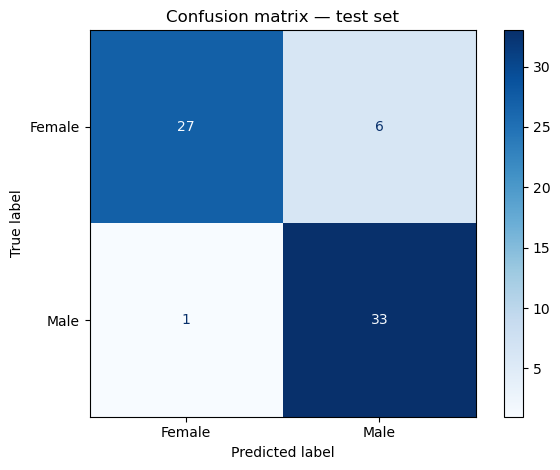

In [4]:
y_pred = pipeline.predict(X_test)

print(classification_report(y_test, y_pred, target_names=le_sex.classes_))

cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=le_sex.classes_)
disp.plot(cmap='Blues')
plt.title('Confusion matrix — test set')
plt.tight_layout()
plt.show()

### 5. Stratified 5-fold cross-validation (full clean dataset)

In [6]:
cv = StratifiedKFold(n_splits=10, shuffle=True)
cv_scores = cross_val_score(pipeline, X, y, cv=cv, scoring='accuracy')

print(f"CV scores:  {cv_scores.round(3)}")
print(f"Mean:       {cv_scores.mean():.3f}")
print(f"Std:        {cv_scores.std():.3f}")

CV scores:  [0.941 0.882 0.941 0.939 0.848 0.879 0.939 0.939 0.879 0.97 ]
Mean:       0.916
Std:        0.038


### 6. Feature importances

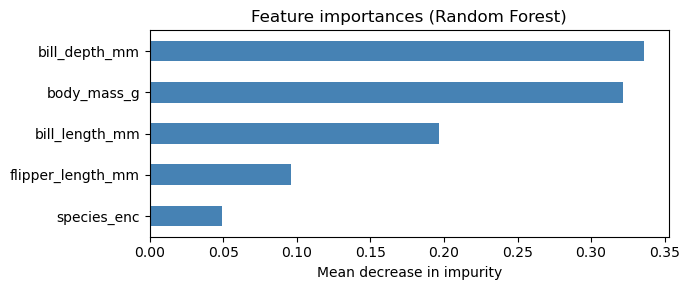

In [7]:
importances = pipeline.named_steps['clf'].feature_importances_
feat_imp = pd.Series(importances, index=feature_cols).sort_values(ascending=True)

feat_imp.plot(kind='barh', color='steelblue', figsize=(7, 3))
plt.title('Feature importances (Random Forest)')
plt.xlabel('Mean decrease in impurity')
plt.tight_layout()
plt.show()

### 7. Predict sex for the 9 unknown rows

In [8]:
# Encode species in the unknown-sex df using the same fitted encoder
penguins_unknown_sex = pd.read_csv('./data/penguins_unknown_sex.csv')
unknown = penguins_unknown_sex.copy()
unknown['species_enc'] = le_species.transform(unknown['species'])

X_unknown = unknown[feature_cols]

predicted_encoded = pipeline.predict(X_unknown)
predicted_proba   = pipeline.predict_proba(X_unknown)

unknown['predicted_sex']        = le_sex.inverse_transform(predicted_encoded)
unknown['confidence']           = predicted_proba.max(axis=1).round(3)

result_cols = ['species', 'island', 'bill_length_mm', 'bill_depth_mm',
               'flipper_length_mm', 'body_mass_g', 'predicted_sex', 'confidence']

print(unknown[result_cols].to_string(index=True))

  species     island  bill_length_mm  bill_depth_mm  flipper_length_mm  body_mass_g predicted_sex  confidence
0  Adelie  Torgersen            34.1           18.1              193.0       3475.0        Female       0.864
1  Adelie  Torgersen            42.0           20.2              190.0       4250.0          Male       0.998
2  Adelie  Torgersen            37.8           17.1              186.0       3300.0        Female       0.995
3  Adelie  Torgersen            37.8           17.3              180.0       3700.0        Female       0.838
4  Adelie      Dream            37.5           18.9              179.0       2975.0        Female       0.769
5  Gentoo     Biscoe            44.5           14.3              216.0       4100.0        Female       0.992
6  Gentoo     Biscoe            46.2           14.4              214.0       4650.0        Female       0.998
7  Gentoo     Biscoe            47.3           13.8              216.0       4725.0        Female       0.957
8  Gentoo 

In [16]:
df.groupby(['species', 'sex'])[['body_mass_g', 'bill_depth_mm', 'bill_length_mm']].mean()

body_mass_g  bill_depth_mm  bill_length_mm
species   sex                                               
Adelie    Female  3368.835616      17.621918       37.257534
          Male    4043.493151      19.072603       40.390411
Chinstrap Female  3527.205882      17.588235       46.573529
          Male    3938.970588      19.252941       51.094118
Gentoo    Female  4679.741379      14.237931       45.563793
          Male    5484.836066      15.718033       49.473770

In [ ]:
# Combine clean dataset with the 9 now-predicted rows
unknown_filled = penguins_unknown_sex.copy()
unknown_filled['sex'] = unknown['predicted_sex']

penguins_full = pd.concat([penguins_clean, unknown_filled], ignore_index=True)

print(f"penguins_clean:  {penguins_clean.shape[0]} rows")
print(f"unknown rows:    {unknown_filled.shape[0]} rows")
print(f"penguins_full:   {penguins_full.shape[0]} rows")
print(f"\nNull counts:\n{penguins_full.isnull().sum()}")

In [ ]:
penguins_full.to_csv('./data/penguins_full.csv', index=False)

In [ ]:
penguins_clean['sex'].value_counts()